# SpiRob CNN Vision Training - Mjlab-SpiRob-EggToBucket-Vision


## 1. Check the GPU

In [ ]:
!nvidia-smi

## 2. Mount Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Adjust if you used a different folder name.
DRIVE_ROOT = "/content/drive/MyDrive/spirob_vision"

!ls -la "{DRIVE_ROOT}"
!ls -la "{DRIVE_ROOT}/vision"


## 3. Install uv and clone the base repository




In [ ]:
!curl -LsSf https://astral.sh/uv/install.sh | sh
import os
os.environ["PATH"] = f"/root/.local/bin:{os.environ['PATH']}"
!uv --version


In [ ]:
# Section 3 — Clone the repository

%cd /content

!rm -rf /content/spirob-mjlab

!git clone https://github.com/YADlin/spirob-mjlab.git

%cd /content/spirob-mjlab

!git rev-parse HEAD


The clone must produce `/content/spirob-mjlab`. Verify:

In [ ]:
!ls /content/spirob-mjlab

## 4. Copy the vision/ package in and register the task




In [ ]:
%cd /content/spirob-mjlab

DRIVE_ROOT = "/content/drive/MyDrive/spirob_vision"

# 1. copy your vision package into the cloned repo
!mkdir -p src/spirob_mjlab/vision
!cp "{DRIVE_ROOT}/vision/"*.py src/spirob_mjlab/vision/
!ls -la src/spirob_mjlab/vision/

# 2. append the one-line registration (idempotent)
!grep -q "from spirob_mjlab import vision" src/spirob_mjlab/__init__.py \
  || echo "from spirob_mjlab import vision  # noqa: F401" >> src/spirob_mjlab/__init__.py
!tail -3 src/spirob_mjlab/__init__.py

# 3. copy the pre-flight test if you saved it to Drive
!cp "{DRIVE_ROOT}/test_vision_pipeline.py" . 2>/dev/null || echo "(no test file on Drive - skipping)"


## 5. Sync the locked environment



In [ ]:
%cd /content/spirob-mjlab
!uv python install 3.12.3
!uv sync --frozen


## 6. Verify CUDA, assets, and task registration

The final check must list **Mjlab-SpiRob-EggToBucket-Vision** alongside
the base Stage1 task.


In [8]:
%cd /content/spirob-mjlab
!uv run python --version
!uv run python -c "import torch; print('CUDA:', torch.cuda.is_available(), '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')"
!uv run python tools/validate_assets.py
!uv run list-envs | grep SpiRob


/content/spirob-mjlab
Python 3.12.3
CUDA: True | Tesla T4
Package root: /content/spirob-mjlab

Checking XML files:
  OK      src/spirob_mjlab/assets/spirob_robot.xml
  OK      src/spirob_mjlab/assets/spirob_egg.xml
  OK      src/spirob_mjlab/assets/spirob_pedestal.xml
  OK      src/spirob_mjlab/assets/spirob_bucket.xml

Checking robot mesh files referenced by spirob_robot.xml:
  OK      src/spirob_mjlab/assets/meshes/link_001.stl
  OK      src/spirob_mjlab/assets/meshes/link_002.stl
  OK      src/spirob_mjlab/assets/meshes/link_003.stl
  OK      src/spirob_mjlab/assets/meshes/link_004.stl
  OK      src/spirob_mjlab/assets/meshes/link_005.stl
  OK      src/spirob_mjlab/assets/meshes/link_006.stl
  OK      src/spirob_mjlab/assets/meshes/link_007.stl
  OK      src/spirob_mjlab/assets/meshes/link_008.stl
  OK      src/spirob_mjlab/assets/meshes/link_009.stl
  OK      src/spirob_mjlab/assets/meshes/link_010.stl
  OK      src/spirob_mjlab/assets/meshes/link_011.stl
  OK      src/spirob_mjlab

Confirm the active reward weights match the intended configuration.

In [10]:
%%writefile /content/spirob-mjlab/check_weights.py
from spirob_mjlab.vision.vision_env_cfg import spirob_vision_env_cfg

cfg = spirob_vision_env_cfg(play=True)
for name, term in cfg.rewards.items():
    print(f"{name}: {term.weight}")

Writing /content/spirob-mjlab/check_weights.py


## 7. Pre-flight test


In [ ]:
%cd /content/spirob-mjlab
!uv run python test_vision_pipeline.py


## 8. Training run


In [ ]:
%cd /content/spirob-mjlab
!uv run train Mjlab-SpiRob-EggToBucket-Vision \
  --env.scene.num-envs 16 \
  --agent.max-iterations 500 \
  --agent.seed 42 \
  --agent.logger tensorboard \
  --agent.run-name vision-v3-500


## 9. TensorBoard

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/spirob-mjlab/logs/rsl_rl


## 10. Save results to Drive



In [ ]:
DRIVE_ROOT = "/content/drive/MyDrive/spirob_vision"
!mkdir -p "{DRIVE_ROOT}/logs"
!cp -r /content/spirob-mjlab/logs/rsl_rl "{DRIVE_ROOT}/logs/"
!ls -la "{DRIVE_ROOT}/logs/rsl_rl"


## 11. Inspect the camera view

Saves one frame from spirob camera - the view the CNN actually learns
from to confirm the workspace (robot, egg, bucket) is correctly framed.


In [15]:
%%writefile /content/spirob-mjlab/save_camera_frame.py
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from mjlab.envs import ManagerBasedRlEnv
from spirob_mjlab.vision.vision_env_cfg import spirob_vision_env_cfg
from spirob_mjlab.vision import vision_mdp

env = ManagerBasedRlEnv(cfg=spirob_vision_env_cfg(play=True) ,device="cuda")
env.reset()
img = vision_mdp.camera_rgb_image(env)[0].permute(1, 2, 0).detach().cpu().numpy()

plt.figure(figsize=(6, 4.5))
plt.imshow(img)
plt.title("spirob_camera - what the CNN sees")
plt.axis("off")
plt.savefig("/content/spirob-mjlab/cnn_view.png", dpi=120, bbox_inches="tight")
print("saved cnn_view.png", img.shape)


Writing /content/spirob-mjlab/save_camera_frame.py


/content/spirob-mjlab
Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla T4" (15 GiB, sm_75, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0
Module mujoco_warp._src.smooth cf7a289 load on device 'cuda:0' took 5.25 ms  (cached)
Module mujoco_warp._src.collision_driver 621a3f9 load on device 'cuda:0' took 0.64 ms  (cached)
Module _nxn_broadphase__locals__kernel_4ee3649d 4ee3649 load on device 'cuda:0' took 0.60 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_c1aa383f c1aa383 load on device 'cuda:0' took 2.88 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_85133f97 85133f9 load on device 'cuda:0' took 2.05 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_15a19499 15a1949 load on device 'cuda:0' took 2.27 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_713b615b 713b615 load on device 'cuda:0' took 3.28 ms  (cached)
Module _primitive_narrowphase__locals__primiti

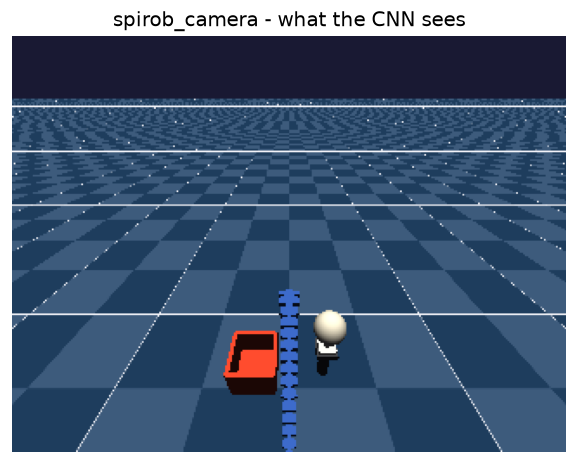

In [16]:
%cd /content/spirob-mjlab
!uv run python save_camera_frame.py
from IPython.display import Image
Image("/content/spirob-mjlab/cnn_view.png")
